In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Modules
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# Set style for plots
sns.set(style="whitegrid")

In [3]:
# Load Heart Disease dataset from a stable GitHub URL
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
print(f"Downloading data from: {url}...")

df = pd.read_csv(url)

# Display first 5 rows to verify
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# 1. Separate Features (X) and Target (y)
X = df.drop('target', axis=1)  # All columns except the answer
y = df['target']               # The answer (1 = Heart Disease, 0 = Healthy)

# 2. Scale the features (Important for Logistic Regression!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully.")
print(f"Feature shape: {X_scaled.shape}")

Data scaled successfully.
Feature shape: (303, 13)


In [5]:
# Initialize K-Fold (10 splits)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

# Run Cross-Validation
cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')

print("--- K-Fold Cross-Validation Results ---")
print(f"Scores for each fold: {cv_scores}")
print(f"Average Accuracy:     {cv_scores.mean() * 100:.2f}%")

--- K-Fold Cross-Validation Results ---
Scores for each fold: [0.80645161 0.93548387 0.74193548 0.83333333 0.83333333 0.83333333
 0.7        0.8        0.86666667 0.86666667]
Average Accuracy:     82.17%


In [6]:
# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Detailed Performance Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (Low False Positives)")
print(f"Recall:    {recall:.4f}     (Low False Negatives - Critical for Health!)")
print(f"F1 Score:  {f1:.4f}       (Balance between Precision & Recall)")

--- Detailed Performance Metrics ---
Accuracy:  0.8525
Precision: 0.8710  (Low False Positives)
Recall:    0.8438     (Low False Negatives - Critical for Health!)
F1 Score:  0.8571       (Balance between Precision & Recall)


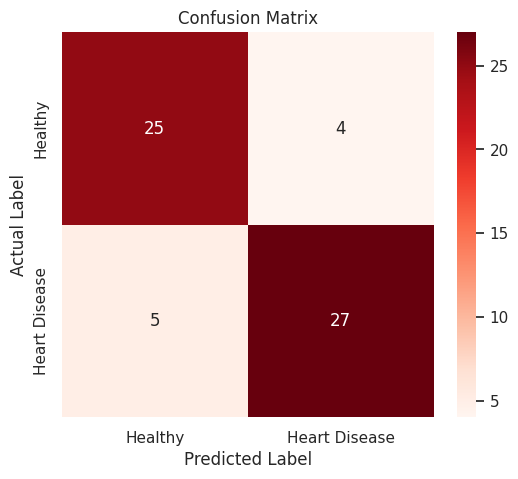

In [7]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()